# MCMC with PyMC

Instead of conjugacy, we sample the posterior with NUTS. This notebook recovers known synthetic parameters, then fits the housing model.

> Requires `pymc>=5` (the original project used deprecated `pymc3`).


In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import arviz as az

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from house_price_predictor.mcmc import (
    fit_bayesian_mcmc, generate_synthetic_regression, posterior_predictive_mean
)
from house_price_predictor import load_housing_data, prepare_xy


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [intercept, beta, sigma]


Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 1 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


Truth: {'intercept': 20.0, 'sigma': 0.5, 'beta[0]': 0.2, 'beta[1]': 0.4}
Posterior means: {'intercept': 19.925892413994237, 'sigma': 0.5361649253775417, 'beta[0]': 0.2665674597440003, 'beta[1]': 0.3701839779123796}


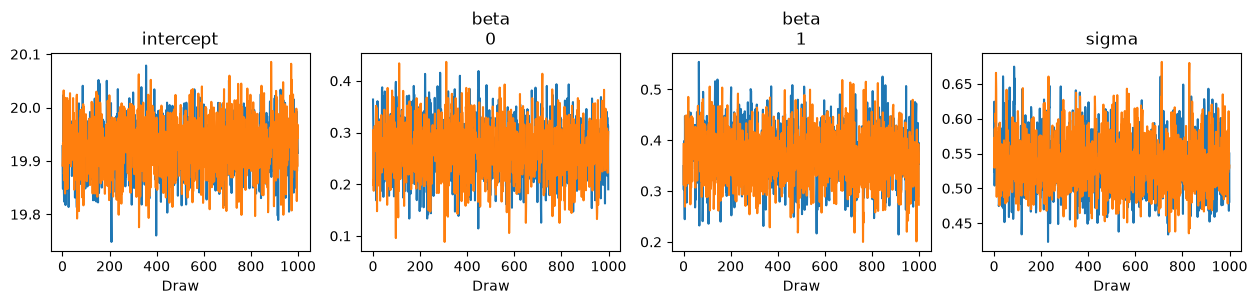

In [2]:
X_syn, y_syn, truth = generate_synthetic_regression()
idata_syn, model_syn = fit_bayesian_mcmc(X_syn, y_syn, draws=1000, tune=1000, chains=2)
print("Truth:", truth)
print("Posterior means:", posterior_predictive_mean(idata_syn))
az.plot_trace(idata_syn)
plt.savefig(ROOT / "artifacts" / "mcmc_synthetic_trace.png", dpi=120)
plt.show()


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [intercept, beta, sigma]


Sampling 2 chains for 800 tune and 800 draw iterations (1_600 + 1_600 draws total) took 1 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


Features: ['GrLivArea', 'YearBuilt']
{'intercept': 12.019037932523695, 'sigma': 0.20330523653302457, 'beta[0]': 0.23717501227124302, 'beta[1]': 0.18569542594701144}


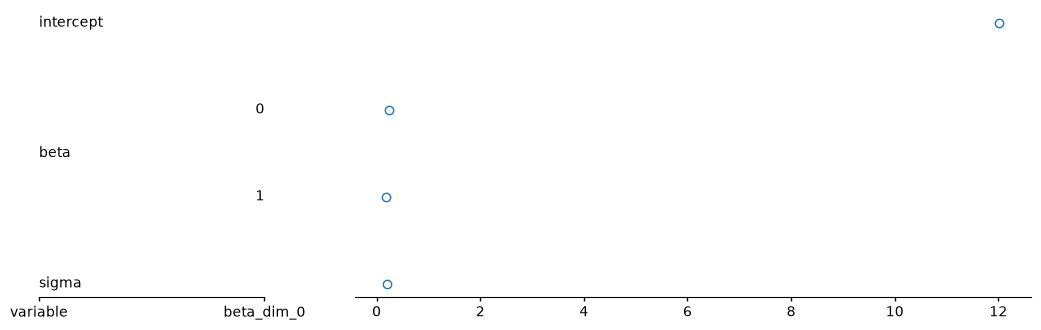

In [3]:
train, _ = load_housing_data()
X, y, feats = prepare_xy(train, features=["GrLivArea", "YearBuilt"], log_target=True)
# Subsample for a faster interactive demo; increase draws for publication-quality traces
rng = np.random.default_rng(0)
idx = rng.choice(len(y), size=400, replace=False)
idata_h, model_h = fit_bayesian_mcmc(X[idx], y[idx], draws=800, tune=800, chains=2)
print("Features:", feats)
print(posterior_predictive_mean(idata_h))
az.plot_forest(idata_h, var_names=["intercept", "beta", "sigma"], combined=True)
plt.savefig(ROOT / "artifacts" / "mcmc_housing_posterior.png", dpi=120)
plt.show()
